In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import os
from pyspark.sql import Window

In [2]:
spark = SparkSession.builder \
    .appName("VenchiDataLoading") \
    .getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/10 22:57:46 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/05/10 22:57:47 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


## Read Data

In [3]:
# 1. perform cd..
current_path = os.getcwd()
parent_path = os.path.dirname(current_path)

# 2. Construct absolute paths using os.path.join 
# This automatically handles slashes correctly for Mac/Linux/Windows
accounts_path = os.path.join(parent_path, 'data', 'accounts.parquet')
interactions_path = os.path.join(parent_path, 'data', 'interactions.parquet')
products_path = os.path.join(parent_path, 'data', 'products.txt')
sales_path = os.path.join(parent_path, 'data', 'sales.parquet')

# 3. Read the data in Spark
# Spark will now receive the full, absolute path (e.g., /Users/Name/Project/data/accounts.parquet)
accounts_df = spark.read.parquet(accounts_path)
accounts_df.printSchema()
interactions_df = spark.read.parquet(interactions_path)
interactions_df.printSchema()
sales_df = spark.read.parquet(sales_path)
sales_df.printSchema()
products_df = spark.read.csv(products_path, sep='\t', header=True, inferSchema=True)
products_df.printSchema()

root
 |-- account_id: string (nullable = true)
 |-- hct: long (nullable = true)
 |-- staff: long (nullable = true)
 |-- turnover_m_usd: long (nullable = true)
 |-- brand_loyalty: long (nullable = true)
 |-- timestamp: string (nullable = true)

root
 |-- interaction_id: string (nullable = true)
 |-- channel: string (nullable = true)
 |-- duration_mins: long (nullable = true)
 |-- response: string (nullable = true)
 |-- topic: string (nullable = true)
 |-- date: string (nullable = true)
 |-- account_id: string (nullable = true)
 |-- product_id: string (nullable = true)

root
 |-- sale_id: string (nullable = true)
 |-- date: string (nullable = true)
 |-- account_id: string (nullable = true)
 |-- product_id: string (nullable = true)

root
 |-- product_id: string (nullable = true)
 |-- maturity: string (nullable = true)
 |-- price: integer (nullable = true)
 |-- category: string (nullable = true)
 |-- patent_id: string (nullable = true)



### Data Cleaning

In [4]:
accounts_clean = accounts_df.filter(F.col("account_id").isNotNull())

interactions_clean = interactions_df.filter(F.col("account_id").isNotNull()) \
    .withColumn("topic_clean", F.lower(F.trim(F.col("topic")))) \
    .withColumn("channel_clean", F.lower(F.trim(F.col("channel")))) \
    .withColumn("response_clean", F.lower(F.trim(F.col("response"))))

sales_clean = sales_df.filter(F.col("account_id").isNotNull())
products_clean = products_df.filter(F.col("product_id").isNotNull())

In [5]:
accounts_clean.groupBy("account_id").count().orderBy('count').filter(F.col("count") > 1).toPandas()

,account_id,count
0,d1022401b7eec8871ae15060675defd8,2
1,0ffe7466d9271fdea80561895e646212,2
2,edba0822938758da14ea7bf2115f33a5,2
3,c8937bf01102a4c633d99c2789776ab2,2
4,fb8a2c3a0a50442354fe11ae6b9f9d21,2
...,...,...
2131,fd242bcbfb732223d528a501ccfcbc7d,3
2132,01459f98eb6004b1acec895aad76ed64,3
2133,04c6f523dbbf07accf50428134daf4d5,3
2134,0368996b1a19e1aa1034363420a95fe5,3


In [6]:
# Order by timestamp DESCENDING (newest first)
latest_window = Window.partitionBy("account_id").orderBy(F.col("timestamp").desc())

# Keep only the newest record per account
deduplicated_accounts = (
    accounts_clean
    .withColumn("row_num", F.row_number().over(latest_window))
    .filter(F.col("row_num") == 1)
    .drop("row_num") # Drop the helper column when done
)

In [7]:
accounts_clean = deduplicated_accounts

In [8]:
accounts_clean.groupBy("account_id").count().orderBy('count').filter(F.col("count") > 1).toPandas()

,account_id,count


In [9]:
sales_clean.groupBy("sale_id").count().orderBy('count').filter(F.col("count") > 1).toPandas()

,sale_id,count


In [10]:
interactions_clean.groupBy("interaction_id").count().orderBy('count').filter(F.col("count") > 1).toPandas()

,interaction_id,count


In [11]:
products_clean.groupBy("product_id").count().orderBy('count').filter(F.col("count") > 1).toPandas()

,product_id,count


## Task 1

### KPI 1: Total Revenue Generated

In [12]:
sales_with_price = sales_clean.join(products_clean, on="product_id", how="left")

In [13]:
# Aggregate revenue per customer
kpi_revenue = sales_with_price.groupBy("account_id").agg(
    F.sum("price").alias("total_revenue")
)

In [14]:
kpi_revenue.show(10)

+--------------------+-------------+
|          account_id|total_revenue|
+--------------------+-------------+
|e1672d506568deedf...|       121980|
|cb04cb651869ca904...|        56680|
|a054955a13c04e9aa...|       106884|
|115d1256179d8ca02...|        89245|
|ccaf873af5b6fdd3b...|        93540|
|2aca7152120b6433f...|        39077|
|caf1c34f21405ceb6...|        68992|
|79f393197ee0b3251...|        45490|
|0ff82ad074e663021...|        63555|
|21fc105190774346e...|        63909|
+--------------------+-------------+
only showing top 10 rows


### KPI 2: Number of sales interactions in the last 6 months

In [15]:
max_date_row = interactions_clean.select(F.max("date").alias("latest_date")).collect()[0]
latest_date = max_date_row["latest_date"]
print(f"Latest interaction date: {latest_date}")

Latest interaction date: 2021-02-05T00:00:00.000Z


In [16]:
sales_interactions_6m = interactions_clean.filter(
    (F.col("date") >= F.date_sub(F.lit(latest_date), 180))
)
sales_interactions_6m.show(10)

+--------------------+------------+-------------+--------+-------------------+--------------------+--------------------+--------------------+-------------------+-------------+--------------+
|      interaction_id|     channel|duration_mins|response|              topic|                date|          account_id|          product_id|        topic_clean|channel_clean|response_clean|
+--------------------+------------+-------------+--------+-------------------+--------------------+--------------------+--------------------+-------------------+-------------+--------------+
|9e8a83833a5a5dafb...|       email|            6|positive|against competition|2020-10-17T00:00:...|544feaa1526ef94f1...|2a38ce238f4b3a52b...|against competition|        email|      positive|
|17f65a62b55523036...|face to face|           82|   mixed|  available finance|2021-01-24T00:00:...|f63ebf8ff4a382c2e...|0eed3f6963570b036...|  available finance| face to face|         mixed|
|909f3a6eca8fbf6b7...|face to face|          

In [17]:
# Aggregate count per customer
kpi_recent_sales_interactions = sales_interactions_6m.groupBy("account_id").agg(
    F.count("interaction_id").alias("sales_interactions_last_6m")
)

<Axes: >

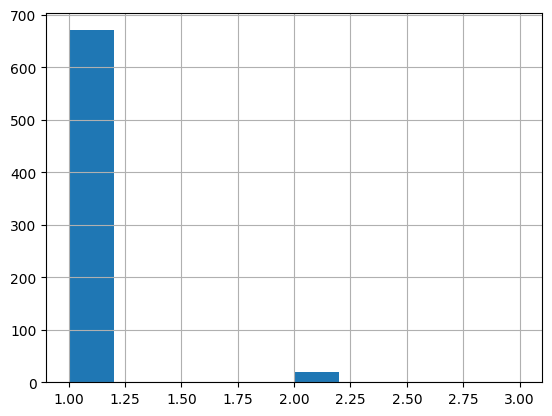

In [18]:
kpi_recent_sales_interactions.toPandas().sales_interactions_last_6m.hist()

### KPI 3 Number of Products that the client bought

In [19]:
kpi_distinct_products = sales_with_price.groupBy("account_id").agg(
    F.countDistinct("product_id").alias("n_distinct_products") 
)

<Axes: >

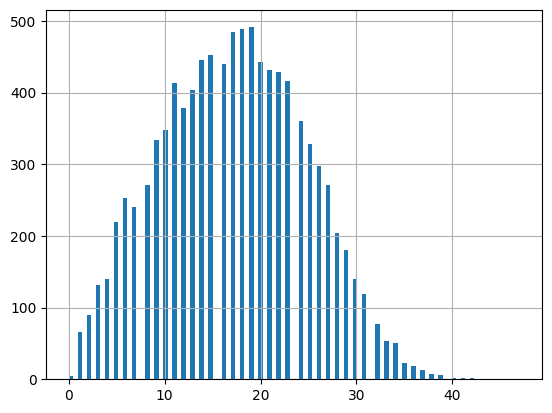

In [20]:
kpi_distinct_products.toPandas().n_distinct_products.hist(bins=100)

In [21]:
# NOT USED IN FINAL MODEL - distribution poorly segmented and skewed, and feature importance low
kpi_distinct_category= sales_with_price.groupBy("account_id").agg(
    F.countDistinct("category").alias("distinct_categories") 
)

<Axes: >

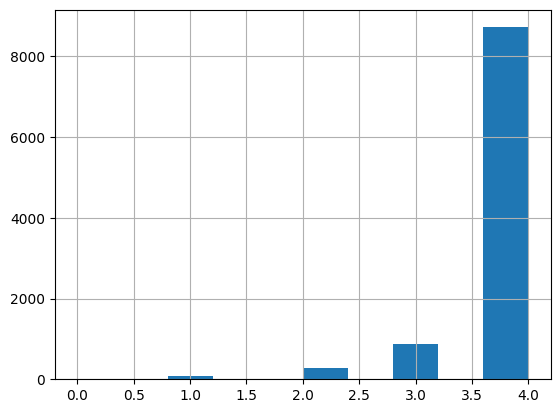

In [22]:
kpi_distinct_category.toPandas().distinct_categories.hist()

### KPI 4: Average interaction for client

In [23]:
kpi_avg_duration = interactions_clean.groupBy("account_id").agg(
    F.round(F.avg("duration_mins"), 2).alias("avg_interaction_duration_mins")
)

In [24]:
kpi_avg_duration.show(5)

+--------------------+-----------------------------+
|          account_id|avg_interaction_duration_mins|
+--------------------+-----------------------------+
|285fffa8d29a9f9b2...|                         14.0|
|26b8c340d56a7e3bb...|                        102.5|
|ae9e95dc1fb78abec...|                         70.5|
|98f62e8b624d99682...|                        121.0|
|fdf8a784a1d444a52...|                       132.67|
+--------------------+-----------------------------+
only showing top 5 rows


<Axes: >

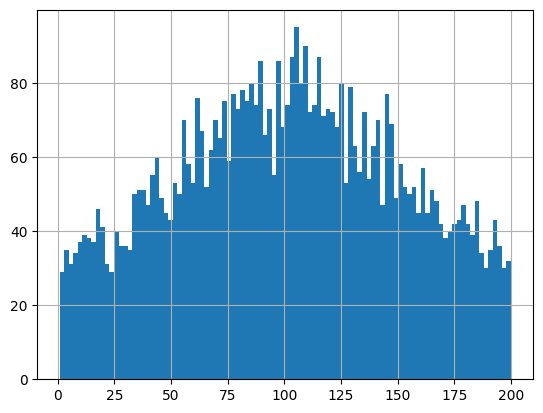

In [25]:
kpi_avg_duration.toPandas().avg_interaction_duration_mins.hist(bins=100)

## TASK 2

### Putting Data Together

In [26]:
analytical_dataset = accounts_clean \
    .join(kpi_revenue, on="account_id", how="left") \
    .join(kpi_recent_sales_interactions, on="account_id", how="left") \
    .join(kpi_distinct_products, on="account_id", how="left") \
    .join(kpi_avg_duration, on="account_id", how="left")
shape = (analytical_dataset.count(), len(analytical_dataset.columns))
print(shape)

(10000, 10)


In [27]:
analytical_dataset.columns

['account_id',
 'hct',
 'staff',
 'turnover_m_usd',
 'brand_loyalty',
 'timestamp',
 'total_revenue',
 'sales_interactions_last_6m',
 'n_distinct_products',
 'avg_interaction_duration_mins']

In [28]:
analytical_dataset = analytical_dataset.fillna({
    "total_revenue": 0,
    "sales_interactions_last_6m": 0,
    "n_distinct_products": 0,
    "avg_interaction_duration_mins": 0
})

<Axes: >

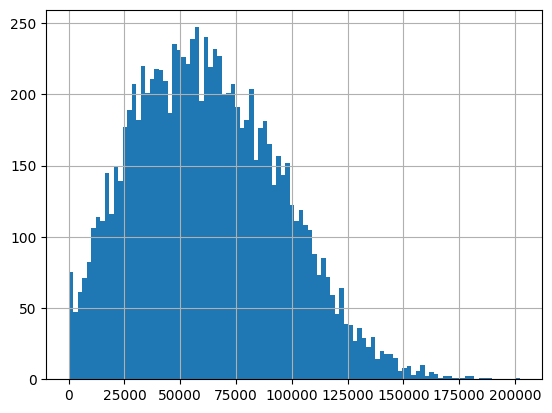

In [29]:
analytical_dataset.toPandas()['total_revenue'].hist(bins=100)

In [30]:
analytical_dataset.show(10)

+--------------------+---+-----+--------------+-------------+-------------------+-------------+--------------------------+-------------------+-----------------------------+
|          account_id|hct|staff|turnover_m_usd|brand_loyalty|          timestamp|total_revenue|sales_interactions_last_6m|n_distinct_products|avg_interaction_duration_mins|
+--------------------+---+-----+--------------+-------------+-------------------+-------------+--------------------------+-------------------+-----------------------------+
|00119d8d5d812849b...| 30|   11|            11|            9|2020-09-03 09:42:12|        27536|                         0|                 10|                          0.0|
|0021b64fc2553dcee...| 68|    9|            83|           11|2020-09-03 09:42:12|        95847|                         0|                 24|                          0.0|
|0027ea1a4498ac70a...| 86|   22|            41|            6|2020-09-03 09:42:12|        10701|                         0|             

### Developing the model

In [31]:
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

In [32]:
# 1. PREPARE DATA FOR MACHINE LEARNING
ml_data = analytical_dataset.fillna(0)

# Define the features we want our model to learn from.
# We mix firmographics (turnover) with our engineered behavioral KPIs.
feature_cols = [
    "turnover_m_usd", 
    "brand_loyalty", 
    "total_revenue", 
    "sales_interactions_last_6m", 
    "n_distinct_products", 
    "avg_interaction_duration_mins"
]

# VectorAssembler combines our individual feature columns into a single vector column called 'features'
assembler = VectorAssembler(inputCols=feature_cols, outputCol="raw_features")
assembled_data = assembler.transform(ml_data)

# StandardScaler normalizes the features so they have a mean of 0 and std dev of 1.
# This prevents large numerical values (like revenue) from dominating the K-Means distance calculations.
scaler = StandardScaler(inputCol="raw_features", outputCol="scaled_features", withStd=True, withMean=True)
scaler_model = scaler.fit(assembled_data)
scaled_data = scaler_model.transform(assembled_data)

# 2. DETERMINE THE NUMBER OF CLUSTERS (k)
# We iterate through potential cluster sizes (2 to 5) and calculate the Silhouette Score.
# A score closer to 1 indicates well-separated, dense clusters.

evaluator = ClusteringEvaluator(predictionCol="prediction", featuresCol="scaled_features", metricName="silhouette")
best_k = 2
best_score = -1

print("Evaluating cluster sizes...")
for k in range(2, 6):
    kmeans = KMeans(featuresCol="scaled_features", k=k, seed=42)
    model = kmeans.fit(scaled_data)
    predictions = model.transform(scaled_data)
    score = evaluator.evaluate(predictions)
    print(f"Silhouette Score for k={k}: {score:.4f}")
    
    if score > best_score:
        best_score = score
        best_k = k

print(f"\nSelected optimal number of clusters: {best_k} (based on highest Silhouette Score)")


Evaluating cluster sizes...


26/05/10 22:58:09 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


Silhouette Score for k=2: 0.4552
Silhouette Score for k=3: 0.5104
Silhouette Score for k=4: 0.4460
Silhouette Score for k=5: 0.4443

Selected optimal number of clusters: 3 (based on highest Silhouette Score)


In [33]:
# 3. TRAIN FINAL MODEL & ASSIGN SEGMENTS

# Train the final model using the best K
final_kmeans = KMeans(featuresCol="scaled_features", k=best_k, seed=42)
final_model = final_kmeans.fit(scaled_data)

# Apply the model to our dataset to generate the 'prediction' column (the segment ID)
enriched_data = final_model.transform(scaled_data)

# Rename 'prediction' to 'customer_segment' for business clarity
enriched_data = enriched_data.withColumnRenamed("prediction", "customer_segment")

In [34]:

# 4. PROFILE THE SEGMENTS
# Calculate the average values for our KPIs per segment to understand who these customers are.
segment_profiles = enriched_data.groupBy("customer_segment").agg(
    F.count("account_id").alias("customer_count"),
    F.round(F.avg("turnover_m_usd"), 2).alias("avg_turnover"),
    F.round(F.stddev("turnover_m_usd"), 2).alias("std_turnover"),  # ← add this
    F.round(F.avg("brand_loyalty"), 2).alias("avg_loyalty"),
    F.round(F.avg("total_revenue"), 2).alias("avg_revenue"),
    F.round(F.avg("sales_interactions_last_6m"), 2).alias("avg_recent_interactions"),
    F.round(F.avg("n_distinct_products"), 2).alias("avg_distinct_products")
).orderBy("customer_segment")

print("\n--- Segment Profiles ---")
segment_profiles.show()


--- Segment Profiles ---
+----------------+--------------+------------+------------+-----------+-----------+-----------------------+---------------------+
|customer_segment|customer_count|avg_turnover|std_turnover|avg_loyalty|avg_revenue|avg_recent_interactions|avg_distinct_products|
+----------------+--------------+------------+------------+-----------+-----------+-----------------------+---------------------+
|               0|          4545|       72.77|       18.88|        6.1|   88353.34|                    0.0|                23.31|
|               1|          4764|        28.8|        19.3|        4.2|   37308.48|                    0.0|                11.08|
|               2|           691|       59.11|       27.63|       4.51|   66873.27|                   1.03|                18.23|
+----------------+--------------+------------+------------+-----------+-----------+-----------------------+---------------------+



### Segment 0 — "High-Value Dormant Giants" · 4,545 customers (45.5%)

**Who they are:** The backbone of FarmCorp's revenue. Large enterprises with the highest average turnover ($72.77M ± $18.88M), the broadest product portfolio (23 distinct products), and the strongest loyalty score (6.1). Their high revenue ($88K avg) combined with zero recent sales interactions indicates these are **self-sufficient, contract-driven accounts** that reorder without requiring active sales engagement.

**Key risk:** The absence of recent touchpoints, despite this segment's commercial weight, creates silent vulnerability. Accounts with no recent contact are more susceptible to competitive displacement, particularly in commodity agricultural markets.

**Defining characteristics:**
- Highest turnover, revenue, and loyalty across all segments
- Widest product breadth — signals strategic partnership maturity
- Zero recent interactions — passive relationship, not actively managed

---

### Segment 1 — "Small & Disengaged" · 4,764 customers (47.8%)

**Who they are:** The largest segment by volume but the weakest commercially. These are smaller enterprises (avg turnover $28.8M) with the narrowest product use (11 products), lowest loyalty (4.2), and lowest revenue ($37K avg). Zero recent interactions, combined with low loyalty, signals **commercial neglect or structural low-fit** with FarmCorp's offering.

**Key nuance:** This segment should not be written off wholesale. A subset of these accounts may be underdeveloped rather than intrinsically low-value — small companies with growth potential that have simply never been properly approached. A responsiveness test (see Business Actions) should precede any deprioritisation decision.

**Defining characteristics:**
- Lowest performance across all six KPIs
- Largest segment by count — aggregate revenue is still material
- No sales activity in the last 6 months

---

### Segment 2 — "Active Mid-Market Prospects" · 691 customers (6.9%)

**Who they are:** The smallest but most strategically urgent segment. Mid-sized companies (avg turnover $59.11M) that are **actively being engaged by FarmCorp sales** — the only segment with recorded interactions in the last 6 months (avg 1.03). Revenue is solid ($66K avg) and product breadth is intermediate (18 products). However, loyalty (4.51) remains close to Segment 1, indicating that the sales effort **has not yet converted into retention**.

**Key nuance:** The high standard deviation in turnover ($27.63) reveals significant heterogeneity within this group — it likely contains a mix of large accounts being re-engaged and genuine mid-market prospects being onboarded for the first time. Disaggregating this segment further (e.g. by account age or region) would improve targeting precision.

**Defining characteristics:**
- Only segment with active sales interactions
- Low loyalty despite ongoing engagement — conversion is the critical KPI
- Heterogeneous turnover distribution — not a uniform group


### Business Actions

| Segment | Priority | Recommended Action |
|---|---|---|
| **0** — High-Value Dormant Giants | High (retention) | Assign Senior Account Managers for **quarterly strategic reviews**. Focus on relationship preservation and proactive upsell of new product lines. Avoid high-frequency contact — these accounts are self-managed. Monitor for any sign of churn given the absence of recent interactions. |
| **1** — Small & Disengaged | Medium (qualify first) | Launch a **low-cost digital nurturing campaign** (targeted email sequences, seasonal promotions, product webinars). Measure response rate over 60 days. Escalate responsive accounts to a junior sales track; move non-responsive accounts to minimal-touch retention. Do not assign senior sales resources without qualification. |
| **2** — Active Mid-Market Prospects | High (conversion) | Activate a **structured 60-day conversion playbook**: product demonstrations, pilot pricing offers, and loyalty incentive schemes (e.g. volume discounts after the 3rd order). Set loyalty score improvement as the primary sales KPI for Q3. If loyalty stagnates despite sustained interactions, conduct a product-market fit review for this segment. |


## Task 2 - Additional Analysis with sklearn

In [35]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [36]:
feature_cols = [
    "turnover_m_usd", 
    "brand_loyalty", 
    "total_revenue", 
    "sales_interactions_last_6m", 
    "n_distinct_products", 
    "avg_interaction_duration_mins"
]

df_pandas = analytical_dataset.toPandas()

# Select the feature columns for scaling
features = df_pandas[feature_cols].values

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

Evaluating k=2...
Evaluating k=3...
Evaluating k=4...
Evaluating k=5...
Evaluating k=6...
Evaluating k=7...
Evaluating k=8...
Evaluating k=9...
Evaluating k=10...


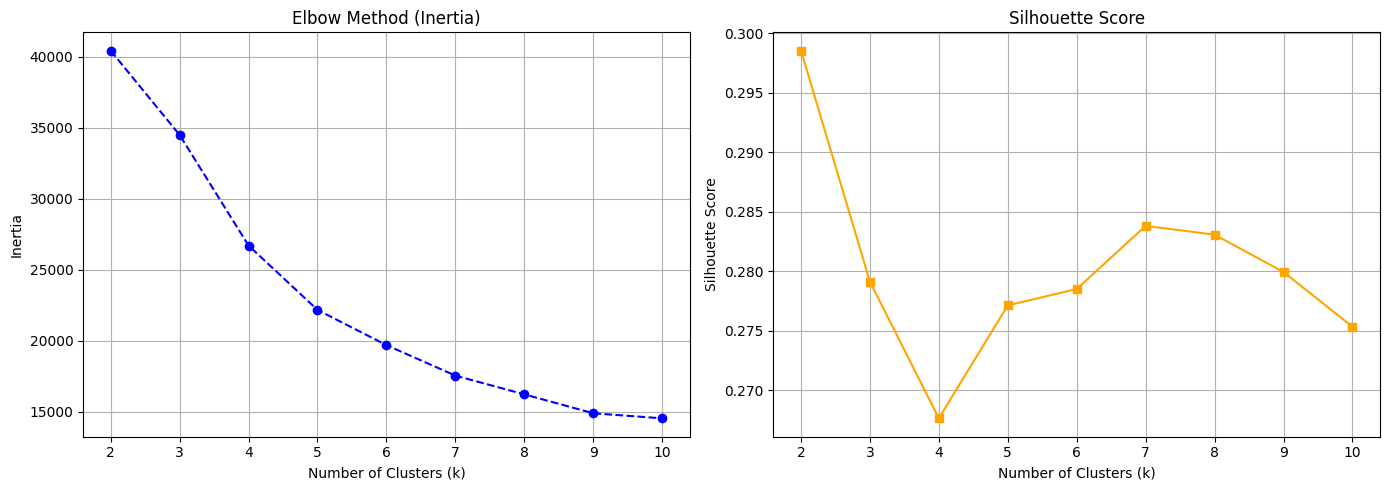

In [37]:
inertia_values = []
silhouette_scores = []

# It is standard practice to test k values between 2 and 10
# (Silhouette score requires at least 2 clusters to calculate)
k_range = range(2, 11) 

for k in k_range:
    print(f"Evaluating k={k}...")
    # 1. Initialize and fit the model for the current k
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_scaled)
    
    # 2. Append the Inertia for the Elbow Method
    inertia_values.append(kmeans.inertia_)
    
    # 3. Calculate and append the Silhouette Score
    # We pass the original scaled data and the cluster labels
    cluster_labels = kmeans.labels_
    score = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(score)

# --- Plotting the Results ---
# Create a figure with 1 row and 2 columns for side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Elbow Method
ax1.plot(k_range, inertia_values, marker='o', linestyle='--', color='blue')
ax1.set_title('Elbow Method (Inertia)')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_xticks(k_range)
ax1.grid(True)

# Plot 2: Silhouette Score
ax2.plot(k_range, silhouette_scores, marker='s', linestyle='-', color='orange')
ax2.set_title('Silhouette Score')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_xticks(k_range)
ax2.grid(True)

plt.tight_layout()
plt.show()

Following further evaluation of the silhouette curve and business interpretability requirements, the final segmentation was refined to **k=5**, which provides a more granular and actionable view of the customer base. The addition of `avg_interaction_duration` as a profiling variable reveals meaningful behavioural differences that were not visible at k=3.

In [38]:
# Train KMeans with k=5
final_kmeans_k5 = KMeans(n_clusters=5, random_state=42, n_init='auto')
final_kmeans_k5.fit(X_scaled)

# Get cluster labels
cluster_labels_k5 = final_kmeans_k5.labels_

# Add cluster assignments to the pandas dataframe
df_pandas['cluster'] = cluster_labels_k5

# Create segment profiles with k=4
segment_summary_k5 = df_pandas.groupby('cluster').agg({
    'account_id': 'count',
    'turnover_m_usd': ['mean', 'std'],
    'brand_loyalty': 'mean',
    'total_revenue': 'mean',
    'sales_interactions_last_6m': 'mean',
    'n_distinct_products': 'mean',
    'avg_interaction_duration_mins': 'mean'
}).round(2)

segment_summary_k5.columns = ['customer_count', 'avg_turnover', 'std_turnover', 'avg_loyalty', 
                               'avg_revenue', 'avg_recent_interactions', 'avg_distinct_products', 'avg_interaction_duration']

print("\n--- Segment Profiles (k=5) ---")
segment_summary_k5


--- Segment Profiles (k=5) ---


,customer_count,avg_turnover,std_turnover,avg_loyalty,avg_revenue,avg_recent_interactions,avg_distinct_products,avg_interaction_duration
cluster,,,,,,,,
0,2283,77.57,15.97,7.67,103405.78,0.00,26.43,55.31
1,2343,23.92,16.26,2.42,25306.16,0.00,7.80,43.59
2,2292,29.78,17.58,7.58,54685.71,0.00,15.63,14.77
3,2392,69.67,18.21,3.00,66378.56,0.00,18.54,97.56
4,690,59.07,27.62,4.50,66707.37,1.03,18.19,101.33


### Cluster 0 — "Elite Loyalists" · 2,283 customers (22.8%)

**Who they are:** The highest-value segment in the dataset. Large enterprises (avg turnover $77.57M ± $15.97M) with the strongest loyalty score (7.67), highest revenue ($103K avg), and the broadest product portfolio (26 distinct products). The moderate interaction duration (55 mins) suggests that when contact does occur, it is strategic and executive-level in nature rather than transactional.

**What they buy:** The widest range of FarmCorp products across all clusters — 26 distinct products on average signals a mature, deeply embedded commercial relationship rather than selective or opportunistic purchasing.

**How loyal are they:** Loyalty at 7.67 is the highest across all clusters by a significant margin. These are genuine long-term partners, not merely high-spending transactional accounts.

**Concrete sales action:** Assign Senior Account Managers for **biannual strategic business reviews**. The focus should be relationship preservation and proactive introduction of new product lines — not volume selling. Given their product breadth, new FarmCorp launches should be trialled with this cluster first. Avoid high-frequency contact, which risks irritating self-sufficient accounts, but ensure at minimum one meaningful executive touchpoint per half-year to guard against silent churn.

---

### Cluster 1 — "Small & Cold" · 2,343 customers (23.4%)

**Who they are:** The weakest segment on every measured dimension. Small enterprises (avg turnover $23.92M) with the lowest loyalty (2.42), lowest revenue ($25K avg), narrowest product use (7.8 products), and the shortest historical interaction duration (43 mins) — suggesting even past conversations were brief and transactional. No recent interactions in the last 6 months.

**What they buy:** A narrow slice of FarmCorp's portfolio (fewer than 8 products on average), likely limited to commodity or entry-level products. There is no evidence of cross-selling success in this cluster.

**How loyal are they:** Loyalty at 2.42 is the lowest in the dataset. These customers have minimal affinity for FarmCorp and are likely purchasing out of convenience or price, not relationship.

**Concrete sales action:** Do not assign dedicated sales resources. Deploy a **low-cost digital qualification campaign** — targeted email sequences and seasonal promotions over 60 days — to identify the subset that is responsive. Accounts that engage should be escalated to a junior sales track for further development; non-responsive accounts should be moved to a minimal-touch automated retention track. Wholesale abandonment of 2,343 accounts is not recommended given the aggregate revenue, but senior sales time should not be spent here without prior qualification.

---

### Cluster 2 — "Loyal but Undermonetised" · 2,292 customers (22.9%)

**Who they are:** The most strategically overlooked segment in the dataset. Smaller companies by turnover ($29.78M avg) but with **loyalty scores (7.58) nearly matching the Elite Loyalists of Cluster 0**. Revenue ($54K avg) and product breadth (15.6 products) are intermediate, but the most telling signal is the shortest interaction duration across all clusters (14.77 mins) — past sales conversations with these accounts have been brief and narrow in scope.

**What they buy:** A mid-range product portfolio (15 products) that has likely remained static for some time, given the absence of recent interactions and the short historical conversation duration. These customers are buying a limited slice of what FarmCorp could offer them.

**How loyal are they:** Highly loyal — 7.58 is among the highest in the dataset. Critically, this loyalty has **not been commercially capitalised on**. These customers already trust FarmCorp but have never been properly upsold.

**Concrete sales action:** This is the **highest-priority upsell opportunity in the entire customer base**. Assign mid-level Account Managers with a structured **product expansion playbook**: map each account's current 15-product portfolio against FarmCorp's full catalogue and identify the top 3–5 adjacent products most relevant to their profile. Initiate outreach with a consultative framing ("based on your current usage, we think X could be relevant") rather than a push-sales approach. Loyalty is already there — the only missing ingredient is a longer, broader conversation.

---

### Cluster 3 — "High-Spend, Low-Affinity" · 2,392 customers (23.9%)

**Who they are:** Large companies (avg turnover $69.67M) with solid revenue ($66K avg) and a respectable product portfolio (18.5 products), but a **low loyalty score (3.00)** that stands in sharp contrast to their commercial scale. The highest historical interaction duration in the dormant clusters (97.56 mins) indicates that past sales conversations were long and complex — yet they have not produced loyalty.

**What they buy:** A broad range of products (18.5 avg), comparable to Cluster 0 in breadth, but without the relationship depth that Cluster 0 demonstrates. This suggests **multi-vendor purchasing behaviour** — these accounts are likely splitting spend across FarmCorp and competitors rather than consolidating.

**How loyal are they:** Loyalty at 3.00 is the second lowest in the dataset, despite being among the largest and highest-spending accounts. Long interactions without loyalty retention is a strong indicator of **price-driven or contract-driven purchasing** rather than genuine preference for FarmCorp.

**Concrete sales action:** Treat this cluster as a **churn risk at the next contract renewal cycle**. Assign Account Managers to conduct structured **loyalty diagnostic conversations** — the goal is to understand what is preventing deeper commitment (pricing, product gaps, competitor relationships). Where feasible, introduce loyalty incentive structures such as preferred pricing tiers or exclusive early access to new products. Track loyalty score movement quarterly; accounts that do not improve within two cycles should be escalated for a commercial relationship review.

---

### Cluster 4 — "Active Prospects" · 690 customers (6.9%)

**Who they are:** The smallest but most commercially urgent cluster. Mid-market companies (avg turnover $59.07M) and the **only cluster with active sales interactions in the last 6 months** (avg 1.03). Historical interaction duration is the highest in the dataset (101.33 mins), confirming that current sales conversations are deep and complex — likely competitive evaluations or multi-stakeholder procurement processes. Loyalty (4.50) remains low despite sustained engagement, indicating the relationship has not yet been won.

**What they buy:** An intermediate product portfolio (18.2 products) comparable to Cluster 3, but the high turnover spread (std $27.62) reveals a heterogeneous group — likely a mix of large accounts being re-engaged and genuine mid-market prospects being onboarded for the first time.

**How loyal are they:** Low loyalty (4.50) relative to the sales investment being made. The gap between interaction effort and loyalty outcome is the defining tension of this cluster.

**Concrete sales action:** Activate a **structured 60-day conversion playbook** immediately. Given the 101-minute average interaction duration, these are not cold leads — sales conversations are already advanced. Priority actions: accelerate proposal timelines, introduce pilot pricing or trial incentives to lower commitment barriers, and deploy loyalty incentive schemes (e.g. volume discounts from the 3rd order onwards). Set **loyalty score improvement** as the primary KPI for the sales team on this cluster in the next quarter. If loyalty does not improve despite continued investment, conduct a product-market fit and competitive positioning review for this segment.

---

### Strategic Priority Summary

| Cluster | Label | Size | Priority | Core Action |
|---|---|---|---|---|
| **0** | Elite Loyalists | 2,283 | Retain | Biannual executive reviews, new product introductions |
| **1** | Small & Cold | 2,343 | Qualify first | Digital nurture campaign, escalate responders only |
| **2** | Loyal but Undermonetised | 2,292 | Upsell | Product expansion playbook — highest ROI opportunity |
| **3** | High-Spend, Low-Affinity | 2,392 | Defend | Loyalty diagnostics, churn prevention at renewal |
| **4** | Active Prospects | 690 | Convert | 60-day conversion playbook, close pipeline now |


## Exporting the enriched_data with segmentation column

In [39]:
# We drop the ML-specific vector columns before saving to keep the final dataset clean.
final_export_df = enriched_data.drop("raw_features", "scaled_features")

output_path = os.path.join(parent_path, 'output', 'enriched_customer_segments.parquet')

# Write to Parquet (overwrite if it already exists)
final_export_df.write.mode("overwrite").parquet(output_path)
print(f"\nEnriched dataset saved to: {output_path}")


Enriched dataset saved to: /Users/matteorossi/Desktop/venchi_project/venchi_jMLE_candidate_pack/output/enriched_customer_segments.parquet


In [42]:
check_exported_df = spark.read.parquet(output_path)
print("\n--- Check read of Enriched Dataset ---")
print('total rows:', check_exported_df.count())
check_exported_df.show(10)


--- Check read of Enriched Dataset ---
total rows: 10000
+--------------------+---+-----+--------------+-------------+-------------------+-------------+--------------------------+-------------------+-----------------------------+----------------+
|          account_id|hct|staff|turnover_m_usd|brand_loyalty|          timestamp|total_revenue|sales_interactions_last_6m|n_distinct_products|avg_interaction_duration_mins|customer_segment|
+--------------------+---+-----+--------------+-------------+-------------------+-------------+--------------------------+-------------------+-----------------------------+----------------+
|00119d8d5d812849b...| 30|   11|            11|            9|2020-09-03 09:42:12|        27536|                         0|                 10|                          0.0|               1|
|0021b64fc2553dcee...| 68|    9|            83|           11|2020-09-03 09:42:12|        95847|                         0|                 24|                          0.0|          